<a href="https://colab.research.google.com/github/s-anubhuti/Retail-Sales-Analysis/blob/main/Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [8]:
df = pd.read_csv("/Retail_Sales.csv")
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


/tmp/ipykernel_4201/660783874.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette=colors)


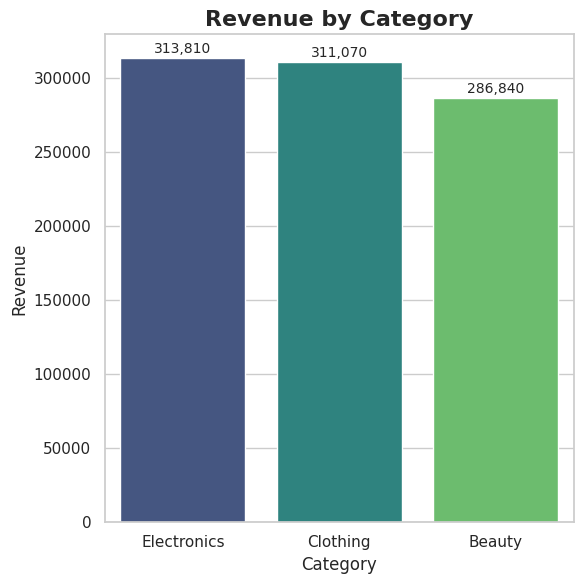

In [25]:
# Aggregate and sort
category_sales = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

# Set style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(6,6))
colors = sns.color_palette("viridis", len(category_sales))
sns.barplot(x=category_sales.index, y=category_sales.values, palette=colors)

# Titles and labels
plt.title("Revenue by Category", fontsize=16, weight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks( ha='center')

# Add values on top of bars
for i, v in enumerate(category_sales.values):
    plt.text(i, v + max(category_sales.values)*0.01, f"{v:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

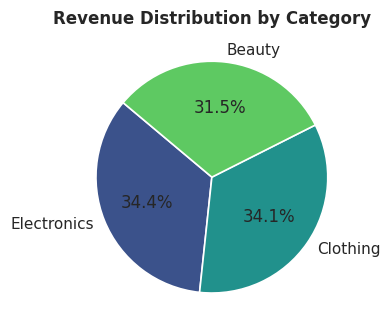

In [71]:
# Aggregate and sort
category_sales = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)

# Pie chart
plt.figure(figsize=(4,4))
colors = sns.color_palette("viridis", len(category_sales))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'white', 'linewidth':1.2}
)

plt.title("Revenue Distribution by Category", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

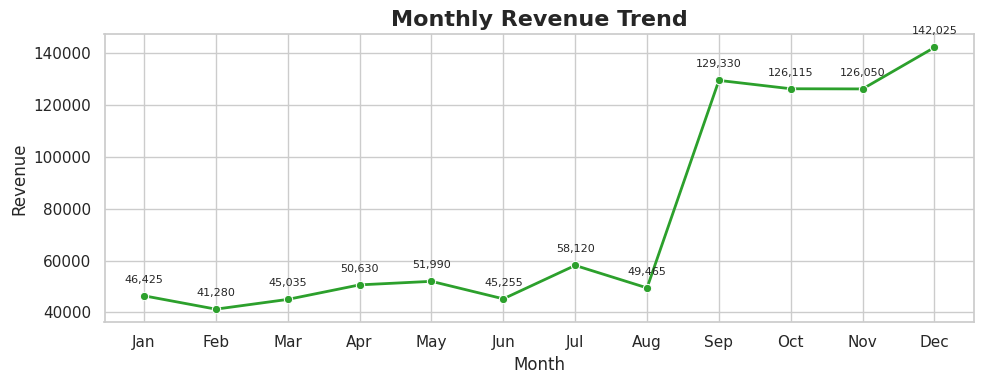

In [37]:
# Ensure 'sale_date' is datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['month'] = df['sale_date'].dt.month

# Aggregate monthly revenue
monthly_sales = df.groupby('month')['total_sale'].sum().reindex(range(1,13), fill_value=0)

# Convert month numbers to names
month_names = [calendar.month_abbr[m] for m in monthly_sales.index]

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10,4))
sns.lineplot(x=month_names, y=monthly_sales.values, marker='o', linewidth=2, color="#2ca02c")

# Titles and labels
plt.title("Monthly Revenue Trend", fontsize=16, weight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Annotate values on points
y_offset = max(monthly_sales.values) * 0.03
for i, v in enumerate(monthly_sales.values):
    plt.text(i, v + y_offset, f"{v:,.0f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4201/2270694753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_sales.index, y=time_sales.values, palette=colors)


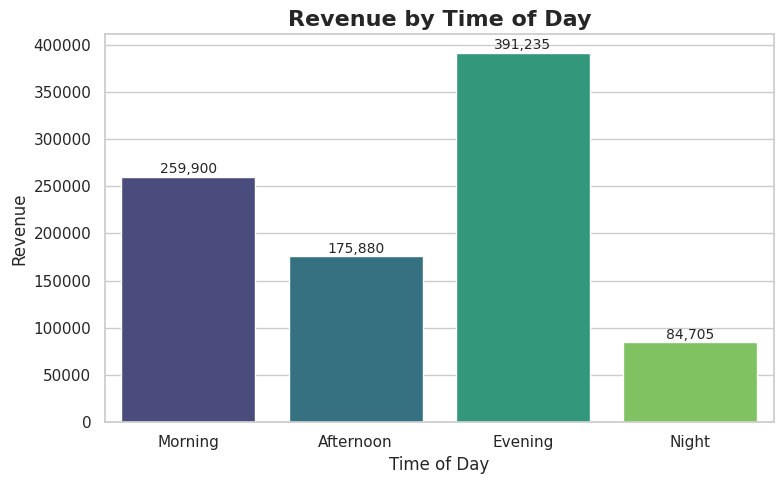

In [45]:
# Ensure order of time buckets
time_order = ["Morning", "Afternoon", "Evening", "Night"]
time_sales = time_sales.reindex(time_order)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8,5))
colors = sns.color_palette("viridis", len(time_sales))
sns.barplot(x=time_sales.index, y=time_sales.values, palette=colors)

# Titles and labels
plt.title("Revenue by Time of Day", fontsize=16, weight='bold')
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Annotate values on top of bars
y_offset = max(time_sales.values)  * 0.001
for i, v in enumerate(time_sales.values):
    plt.text(i, v + y_offset, f"{v:,.0f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4201/1148237968.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.index.astype(str), y=top_customers.values, palette=colors)


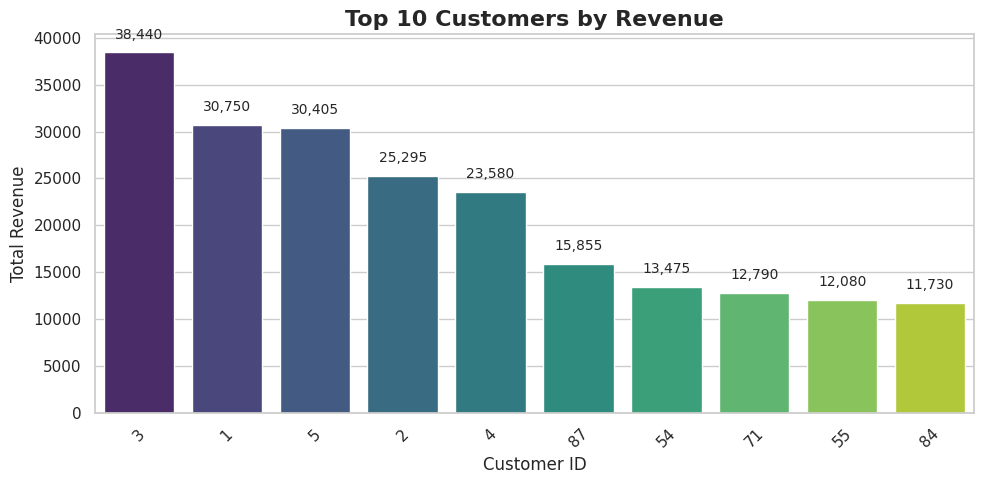

In [46]:
# Aggregate top 10 customers
top_customers = df.groupby('customer_id')['total_sale'].sum().sort_values(ascending=False).head(10)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10,5))
colors = sns.color_palette("viridis", len(top_customers))
sns.barplot(x=top_customers.index.astype(str), y=top_customers.values, palette=colors)

# Titles and labels
plt.title("Top 10 Customers by Revenue", fontsize=16, weight='bold')
plt.xlabel("Customer ID", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)

# Annotate values on top of bars
y_offset = max(top_customers.values) * 0.03
for i, v in enumerate(top_customers.values):
    plt.text(i, v + y_offset, f"{v:,.0f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4201/4117774186.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='revenue', data=gender_sales, palette=colors)


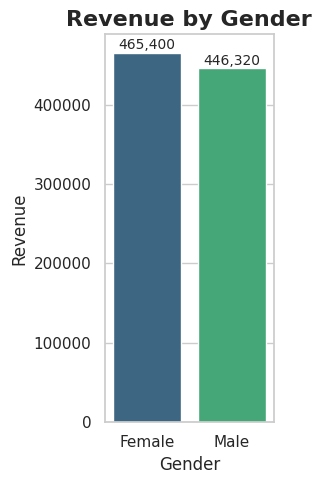

In [66]:
# Aggregate gender stats (without quantity)
gender_sales = df.groupby('gender').agg(
    orders=('total_sale', 'count'),
    revenue=('total_sale', 'sum'),
    avg_order_value=('total_sale', 'mean')
).reset_index()

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(3,5))

# Revenue bar plot
colors = sns.color_palette("viridis", len(gender_sales))
sns.barplot(x='gender', y='revenue', data=gender_sales, palette=colors)

# Titles and labels
plt.title("Revenue by Gender", fontsize=16, weight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Annotate revenue on top of bars
y_offset = max(gender_sales['revenue']) * 0.001
for i, v in enumerate(gender_sales['revenue']):
    plt.text(i, v + y_offset, f"{v:,.0f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()